In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tanushkumaryadav/hhhhh/check_hh.csv


In [29]:
df=pd.read_csv("/kaggle/input/datasets/tanushkumaryadav/hhhhh/check_hh.csv")

In [30]:
df.sample(10)

,formula,choice
683,Pd1Ta1Y1,0
424,B1Re1Rh1,0
516,Al1Mg1Si1,0
406,La1Ti1Y1,0
811,Bi1Cd1Na1,0
493,Ge1Hg1W1,0
658,Ag1Al1Zn1,0
777,B1Re1Zr1,0
307,NiVSn,1
109,FeCrSn,1


In [31]:
!pip install pymatgen

In [32]:
from pymatgen.core import Composition
c=Composition("Al3Ag2As1")
d=Composition("AlAgAs")
cc=list(c.get_el_amt_dict().keys())
ccc=list(c.get_el_amt_dict().values())
print(sorted(c.values()))
print(sorted(d.values()))
print(cc)
print(ccc)

[1.0, 2.0, 3.0]
[1.0, 1.0, 1.0]
['Al', 'Ag', 'As']
[3.0, 2.0, 1.0]


In [33]:
from pymatgen.core import Composition, Element
def parse_mol(formula):
    com=Composition(formula)
    elements = list(com.get_el_amt_dict().keys())
    amounts = list(com.get_el_amt_dict().values())
    X=[Element(elements[0]).X,Element(elements[1]).X, Element(elements[2]).X]
    c, b, a = sorted(X)
    A = elements[X.index(a)]
    B=elements[X.index(b)]
    C=elements[X.index(c)]
    return A,B,C

parse_mol("CoTiSn")
    

('Sn', 'Co', 'Ti')

In [34]:
from pymatgen.core import Element

el = Element("Li")

print(el.group)
print(el.row)
print(el.X)                 # Pauling electronegativity
print(el.atomic_mass)
print(el.atomic_radius)
print(el.full_electronic_structure)

1
2
0.98
6.941 amu
1.45 ang
[(1, 's', 2), (2, 's', 1)]


In [35]:
descriptors = {'t_s': [], 't_p': [], 't_d': [], 't_all': [],'r_AB': [], 'r_AC': [],'r_BC': [], 'en_A': [], 'en_B': [], 'en_C': [],'g_A': [], 
               'g_B': [], 'g_C': [], 'r_A': [], 'r_B': [], 'r_C': [],'m_A': [], 'm_B': [], 'm_C': [],
                'p_A': [], 'p_B': [], 'p_C': []}
def Descriptors(A,B,C):
    el_A=Element(A)
    el_B=Element(B)
    el_C=Element(C)
    q_s,q_p,q_d=0,0,0
    for atom,mul in [(A,1),(B,1),(C,1)]:
        el=Element(atom)
        structure=el.full_electronic_structure
        n_max = max(n for n, l, q in structure)
        for n,l,q in el.full_electronic_structure:
            if(l=='s' and n==n_max):
                q_s+=mul*q
            if(l=='p' and n==n_max):
                q_p+=mul*q
            if(l=='d' and n==n_max-1 and el.group <= 12):
                q_d+=mul*q
    descriptors['t_s'].append(q_s)
    descriptors['t_p'].append(q_p)
    descriptors['t_d'].append(q_d)
    descriptors['t_all'].append(q_s+q_p+q_d)
    R_AB=abs(el_A.atomic_radius-el_B.atomic_radius)
    descriptors['r_AB'].append(R_AB)
    descriptors['en_B'].append(el_B.X)
    descriptors['en_C'].append(el_C.X)
    descriptors['en_A'].append(el_A.X)
    descriptors['g_A'].append(el_A.group)
    descriptors['g_B'].append(el_B.group)
    descriptors['g_C'].append(el_C.group)
    R_AC=abs(el_A.atomic_radius-el_C.atomic_radius)
    descriptors['r_AC'].append(R_AC)
    R_BC=abs(el_B.atomic_radius-el_C.atomic_radius)
    descriptors['r_BC'].append(R_BC)
    descriptors['r_C'].append(el_C.atomic_radius)
    descriptors['r_B'].append(el_B.atomic_radius)
    descriptors['r_A'].append(el_A.atomic_radius)
    descriptors['m_C'].append(el_C.atomic_mass)
    descriptors['m_B'].append(el_B.atomic_mass)
    descriptors['m_A'].append(el_A.atomic_mass)
    descriptors['p_A'].append(el_A.row)
    descriptors['p_B'].append(el_B.row)
    descriptors['p_C'].append(el_C.row)
    


In [36]:
for formula in df['formula']:
    A,B,C=parse_mol(formula)
    Descriptors(A,B,C)

In [37]:
len(descriptors['t_s'])

1212

In [38]:
descriptor_df = pd.DataFrame(descriptors)

In [39]:
descriptor_df.shape

(1212, 22)

In [40]:
descriptor_df.isnull().sum()

t_s      0
t_p      0
t_d      0
t_all    0
r_AB     0
r_AC     0
r_BC     0
en_A     0
en_B     0
en_C     0
g_A      0
g_B      0
g_C      0
r_A      0
r_B      0
r_C      0
m_A      0
m_B      0
m_C      0
p_A      0
p_B      0
p_C      0
dtype: int64

In [41]:
descriptor_df.head()

,t_s,t_p,t_d,t_all,r_AB,r_AC,r_BC,en_A,en_B,en_C,...,g_C,r_A,r_B,r_C,m_A,m_B,m_C,p_A,p_B,p_C
0,5,1,7,13,0.10,0.10,0.0,1.81,1.66,1.54,...,4,1.30,1.4,1.4,69.7230,51.9961,47.867,4,4,4
1,5,1,7,13,0.15,0.15,0.0,1.78,1.66,1.54,...,4,1.55,1.4,1.4,114.8180,51.9961,47.867,5,4,4
2,5,2,7,14,0.30,0.30,0.0,1.90,1.66,1.54,...,4,1.10,1.4,1.4,28.0855,51.9961,47.867,3,4,4
3,5,2,7,14,0.15,0.15,0.0,2.01,1.66,1.54,...,4,1.25,1.4,1.4,72.6400,51.9961,47.867,4,4,4
4,5,2,7,14,0.05,0.05,0.0,1.96,1.66,1.54,...,4,1.45,1.4,1.4,118.7100,51.9961,47.867,5,4,4


In [42]:
df_final = pd.concat([df.reset_index(drop=True),descriptor_df.reset_index(drop=True)],axis=1)

In [43]:
df_final.head()

,formula,choice,t_s,t_p,t_d,t_all,r_AB,r_AC,r_BC,en_A,...,g_C,r_A,r_B,r_C,m_A,m_B,m_C,p_A,p_B,p_C
0,CrTiGa,1,5,1,7,13,0.10,0.10,0.0,1.81,...,4,1.30,1.4,1.4,69.7230,51.9961,47.867,4,4,4
1,CrTiIn,1,5,1,7,13,0.15,0.15,0.0,1.78,...,4,1.55,1.4,1.4,114.8180,51.9961,47.867,5,4,4
2,CrTiSi,1,5,2,7,14,0.30,0.30,0.0,1.90,...,4,1.10,1.4,1.4,28.0855,51.9961,47.867,3,4,4
3,CrTiGe,1,5,2,7,14,0.15,0.15,0.0,2.01,...,4,1.25,1.4,1.4,72.6400,51.9961,47.867,4,4,4
4,CrTiSn,1,5,2,7,14,0.05,0.05,0.0,1.96,...,4,1.45,1.4,1.4,118.7100,51.9961,47.867,5,4,4


In [44]:
df_final.to_csv('With_descriptors.csv',index=False)

In [45]:
X = df_final.drop(columns=['formula', 'choice'])
y = df_final['choice']

In [46]:
print(X.shape)
print(y.shape)

(1212, 22)
(1212,)


In [47]:

print(y.value_counts())

print(y.value_counts(normalize=True))

choice
0    877
1    335
Name: count, dtype: int64
choice
0    0.723597
1    0.276403
Name: proportion, dtype: float64


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [49]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {'n_estimators': [200, 500, 1000],'max_depth': [5, 10, 15, 20, None],'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2'],'class_weight': ['balanced']}

rf = RandomForestClassifier(random_state=42)

search = RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=50,scoring='recall',cv=5,n_jobs=-1,random_state=42)

search.fit(X_train, y_train)

print(search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}


In [50]:
best_params = search.best_params_
print(best_params)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}


In [51]:
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score)

rf_best = RandomForestClassifier(**best_params,random_state=42,n_jobs=-1)

rf_best.fit(X_train, y_train)

prob = rf_best.predict_proba(X_test)[:,1]

for t in [0.2,0.3,0.4,0.5]:
    y_pred = (prob > t).astype(int)

    print(classification_report(y_test, y_pred))
    
    print(confusion_matrix(y_test, y_pred))
    
    print(roc_auc_score(y_test,rf_best.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95       176
           1       0.81      1.00      0.89        67

    accuracy                           0.93       243
   macro avg       0.90      0.95      0.92       243
weighted avg       0.95      0.93      0.94       243

[[160  16]
 [  0  67]]
0.9883819538670284
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       176
           1       0.84      1.00      0.91        67

    accuracy                           0.95       243
   macro avg       0.92      0.96      0.94       243
weighted avg       0.96      0.95      0.95       243

[[163  13]
 [  0  67]]
0.9883819538670284
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       176
           1       0.84      1.00      0.91        67

    accuracy                           0.95       243
   macro avg       0.92      0.96      0.94 

In [52]:
rf_best.fit(X_train,y_train)

y_pred = rf_best.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96       176
           1       0.85      1.00      0.92        67

    accuracy                           0.95       243
   macro avg       0.92      0.97      0.94       243
weighted avg       0.96      0.95      0.95       243



In [53]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_best,X,y,cv=5,scoring='f1')

print(scores)
print(scores.mean())

[0.92198582 0.91156463 0.93055556 0.91156463 0.92957746]
0.921049617529561


In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=20,shuffle=True,random_state=42)

scores = cross_val_score(rf_best,X,y,cv=skf,scoring='f1')

print(scores)
print(scores.mean())
print(scores.std())

[0.79069767 0.87179487 0.94444444 0.97142857 0.88235294 0.97142857
 0.94444444 0.89473684 0.94444444 0.97142857 0.89473684 0.97142857
 0.91891892 0.97142857 0.94444444 0.83333333 0.94117647 0.91428571
 0.88888889 0.94117647]
0.9203509801562217
0.04835206851075998


In [55]:
import pandas as pd

importance = pd.DataFrame({'feature': X.columns,'importance': rf_best.feature_importances_})

importance = importance.sort_values('importance',ascending=False)

print(importance.head(22))

   feature  importance
15     r_C    0.183657
1      t_p    0.112389
9     en_C    0.106274
12     g_C    0.100739
18     m_C    0.086113
16     m_A    0.084922
21     p_C    0.048068
19     p_A    0.043632
2      t_d    0.038889
5     r_AC    0.035955
17     m_B    0.035255
7     en_A    0.030485
20     p_B    0.019330
6     r_BC    0.019104
10     g_A    0.018533
3    t_all    0.013821
8     en_B    0.007995
4     r_AB    0.006448
14     r_B    0.003544
11     g_B    0.002930
13     r_A    0.001646
0      t_s    0.000273


In [56]:
df_final.groupby('choice')['t_all'].value_counts(normalize=True)

choice  t_all
0       17       0.082098
        18       0.066135
        15       0.063854
        20       0.063854
        16       0.061574
        14       0.058153
        19       0.058153
        23       0.055872
        12       0.052452
        13       0.052452
        21       0.052452
        11       0.047891
        22       0.043330
        10       0.039909
        25       0.029647
        9        0.027366
        8        0.025086
        24       0.022805
        27       0.013683
        28       0.013683
        26       0.012543
        7        0.011403
        30       0.006842
        6        0.005701
        29       0.005701
        32       0.005701
        33       0.004561
        34       0.004561
        31       0.002281
        35       0.002281
        36       0.002281
        37       0.002281
        4        0.001140
        5        0.001140
        40       0.001140
1       18       0.161194
        19       0.149254
        17       0.13432

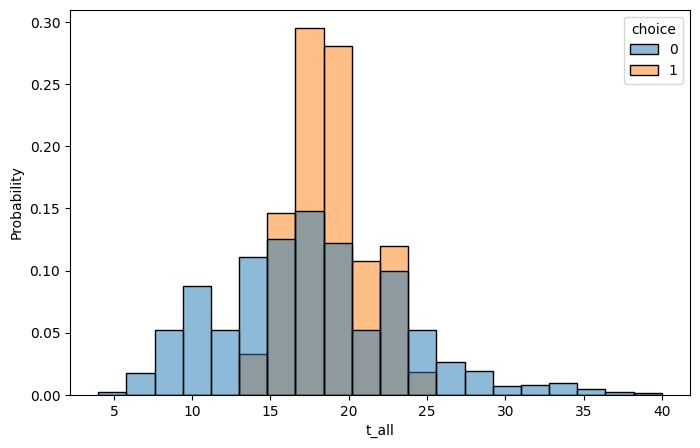

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_final,
    x='t_all',
    hue='choice',
    stat='probability',
    common_norm=False,
    bins=20
)

plt.show()

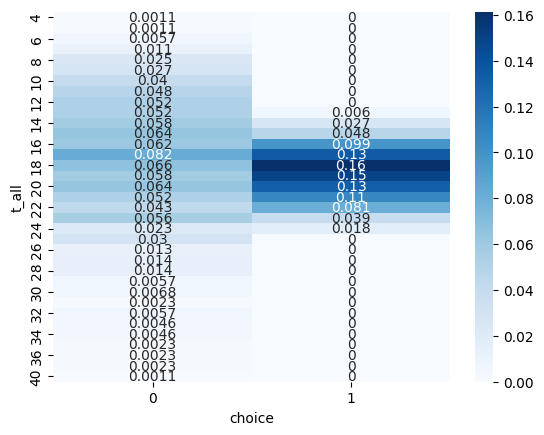

In [58]:
tab = pd.crosstab(
    df_final['t_all'],
    df_final['choice'],
    normalize='columns'
)

sns.heatmap(
    tab,
    annot=True,
    cmap='Blues'
)

plt.show()

In [59]:
df_final.sample(10)

,formula,choice,t_s,t_p,t_d,t_all,r_AB,r_AC,r_BC,en_A,...,g_C,r_A,r_B,r_C,m_A,m_B,m_C,p_A,p_B,p_C
572,Ba1Cu1Mg1,0,5,0,10,15,0.15,0.80,0.65,1.90,...,2,1.35,1.50,2.15,63.546000,24.305000,137.327000,4,3,6
481,Fe1Mo1Nb1,0,4,0,15,19,0.05,0.00,0.05,2.16,...,5,1.45,1.40,1.45,95.940000,55.845000,92.906380,5,4,5
345,Fe1Pb1Sb1,0,6,5,6,17,0.35,0.40,0.05,2.33,...,8,1.80,1.45,1.40,207.200000,121.760000,55.845000,6,5,4
105,FeCrGa,1,5,1,11,17,0.10,0.00,0.10,1.83,...,6,1.40,1.30,1.40,55.845000,69.723000,51.996100,4,4,4
461,Bi1Ru1W1,0,5,3,11,19,0.05,0.25,0.30,2.36,...,15,1.35,1.30,1.60,183.840000,101.070000,208.980400,6,5,6
1131,Be1Cl1Mg1,0,6,5,0,11,0.05,0.50,0.45,3.16,...,2,1.00,1.05,1.50,35.453000,9.012182,24.305000,3,2,3
1092,Ag1Ge1Ir1,0,5,2,17,24,0.10,0.25,0.35,2.20,...,11,1.35,1.25,1.60,192.217000,72.640000,107.868200,6,4,5
1208,Be1Bi1Ca1,0,6,3,0,9,0.55,0.20,0.75,2.02,...,2,1.60,1.05,1.80,208.980400,9.012182,40.078000,6,2,4
1152,Au1Sr1Ti1,0,5,0,12,17,0.05,0.65,0.60,2.54,...,2,1.35,1.40,2.00,196.966569,47.867000,87.620000,6,4,5
885,Ag1Be1Cu1,0,4,0,20,24,0.25,0.55,0.30,1.93,...,2,1.60,1.35,1.05,107.868200,63.546000,9.012182,5,4,2


In [60]:
df_test=df_final.drop(['r_C','en_C','g_C','m_C','p_C'], axis=1)

In [61]:
X = df_test.drop(columns=['formula', 'choice'])
y = df_test['choice']

In [62]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [63]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {'n_estimators': [200, 500, 1000],'max_depth': [5, 10, 15, 20, None],'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2'],'class_weight': ['balanced']}

rf = RandomForestClassifier(random_state=42)

search = RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=50,scoring='recall',cv=5,n_jobs=-1,random_state=42)

search.fit(X_train, y_train)

print(search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}


In [64]:
rf_best.fit(X_train,y_train)

y_pred = rf_best.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.91      0.96       176
           1       0.82      1.00      0.90        67

    accuracy                           0.94       243
   macro avg       0.91      0.96      0.93       243
weighted avg       0.95      0.94      0.94       243



In [65]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_best,X,y,cv=5,scoring='f1')

print(scores)
print(scores.mean())

[0.768      0.87581699 0.91156463 0.92413793 0.93055556]
0.8820150211808861


In [66]:
import pandas as pd

importance = pd.DataFrame({'feature': X.columns,'importance': rf_best.feature_importances_})

importance = importance.sort_values('importance',ascending=False)

print(importance.head(22))

   feature  importance
1      t_p    0.191996
13     m_A    0.145138
5     r_AC    0.122471
6     r_BC    0.111639
2      t_d    0.086666
15     p_A    0.074790
14     m_B    0.049441
3    t_all    0.048890
7     en_A    0.041887
16     p_B    0.032889
9      g_A    0.031028
10     g_B    0.021074
8     en_B    0.016150
4     r_AB    0.011994
12     r_B    0.009567
11     r_A    0.003873
0      t_s    0.000509
